# Кластеризация

In [54]:
import pandas as pd

df = pd.read_csv('data/mall_customers_clustering.csv', index_col=0)
df.head()

,CustomerID,Genre,Age,Income,Score
0,1,Male,19,15000,0.39
1,2,Male,21,15000,0.81
2,3,Female,20,16000,0.06
3,4,Female,23,16000,0.77
4,5,Female,31,17000,0.40


<Axes: xlabel='Income', ylabel='Score'>

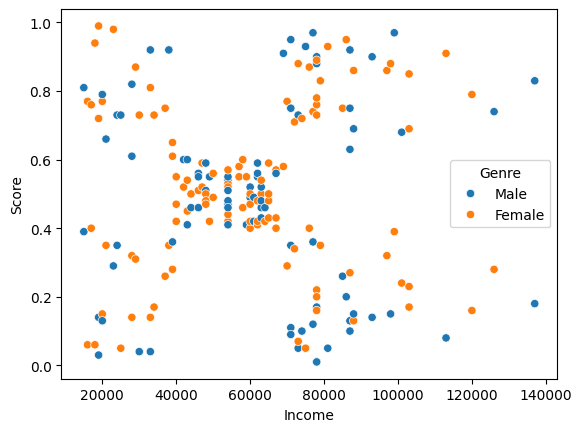

In [55]:
import seaborn as sns
sns.scatterplot(x='Income' , y='Score',data=df , hue='Genre')

In [56]:
x = df.drop(["CustomerID"], axis=1)
X = pd.get_dummies(x)
X.head()

,Age,Income,Score,Genre_Female,Genre_Male
0,19,15000,0.39,False,True
1,21,15000,0.81,False,True
2,20,16000,0.06,True,False
3,23,16000,0.77,True,False
4,31,17000,0.40,True,False


In [57]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3, random_state=42).fit(X)
y_kmeans = k_means.labels_

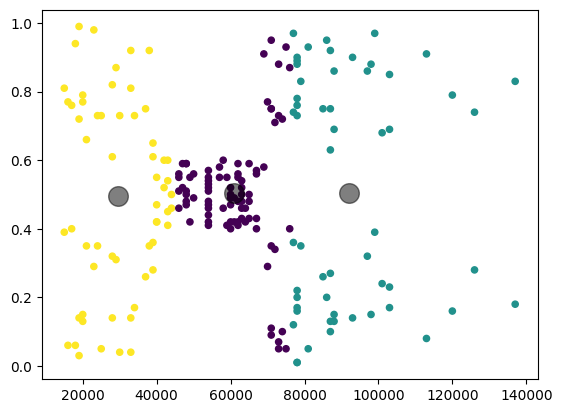

In [58]:
plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

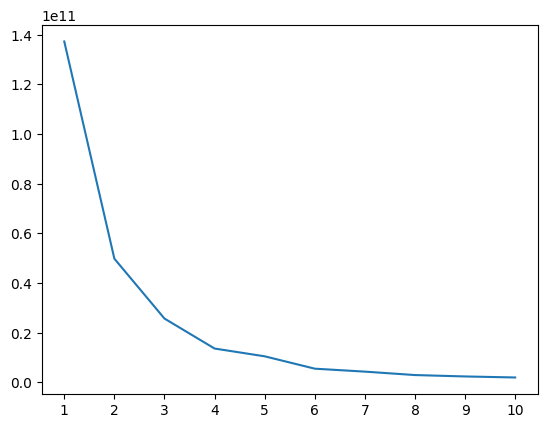

In [59]:
wcss = []
for i in range(1,11):
	k_means = KMeans(n_clusters=i,random_state=42)
	k_means.fit(X)
	wcss.append(k_means.inertia_)
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
_ = plt.show()

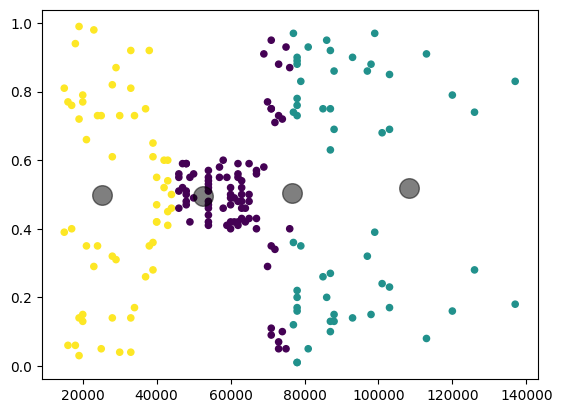

In [60]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X)

plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

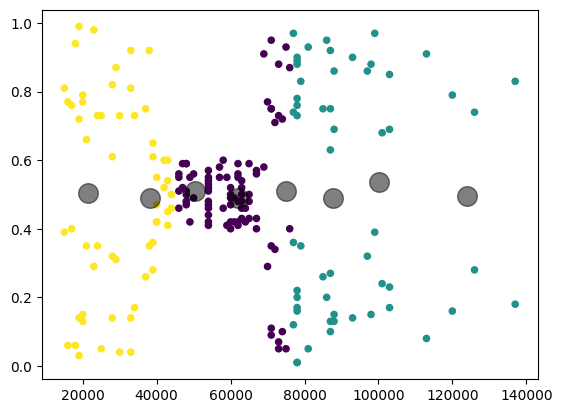

In [61]:
k_means = KMeans(n_clusters=8, random_state=42).fit(X)

plt.scatter(x.Income, x.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Age,Income,Score,Genre_Female,Genre_Male
0,-1.424569,-1.738999,-0.434801,-1.128152,1.128152
1,-1.281035,-1.738999,1.195704,-1.128152,1.128152
2,-1.352802,-1.700830,-1.715913,0.886405,-0.886405
3,-1.137502,-1.700830,1.040418,0.886405,-0.886405
4,-0.563369,-1.662660,-0.395980,0.886405,-0.886405


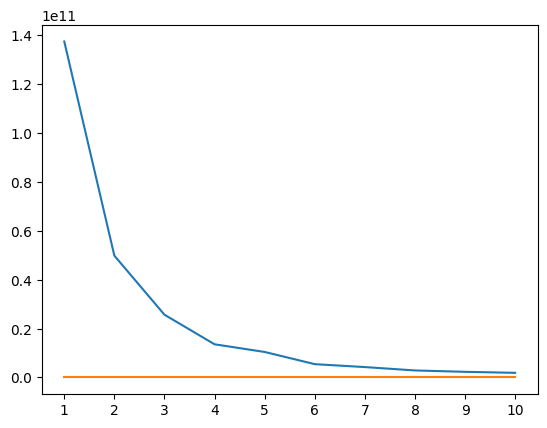

In [63]:
unscaled, scaled = [], []
for i in range(1,11):
	unscaled.append(KMeans(n_clusters=i,random_state=42).fit(X).inertia_)
	scaled.append(KMeans(n_clusters=i,random_state=42).fit(X_scaled).inertia_)
plt.plot(range(1,11),unscaled)
plt.plot(range(1,11),scaled)
plt.xticks(range(1,11))
_ = plt.show()

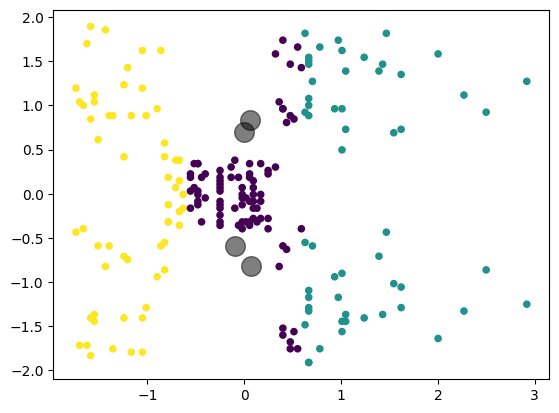

In [64]:
k_means = KMeans(n_clusters=4, random_state=42).fit(X_scaled)

plt.scatter(X_scaled.Income, X_scaled.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='black', s=200, alpha=0.5)
plt.show()

In [65]:
X_flat = X_scaled.drop(["Age", "Genre_Female", "Genre_Male"], axis=1)
X_flat.head()

,Income,Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


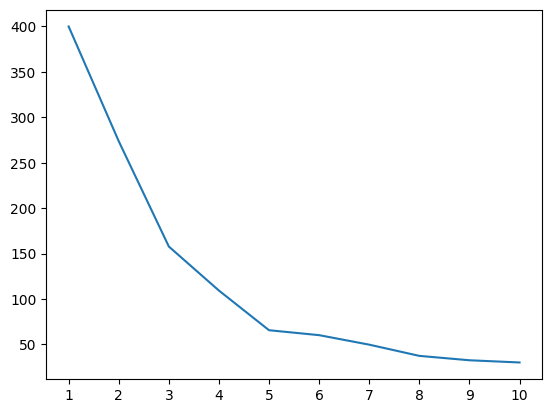

In [66]:
X_flat = X_scaled.drop(["Age", "Genre_Female", "Genre_Male"], axis=1)
X_flat.head()

scaled = []
for i in range(1,11):
	scaled.append(KMeans(n_clusters=i,random_state=42).fit(X_flat).inertia_)
plt.plot(range(1,11),scaled)
plt.xticks(range(1,11))
_ = plt.show()

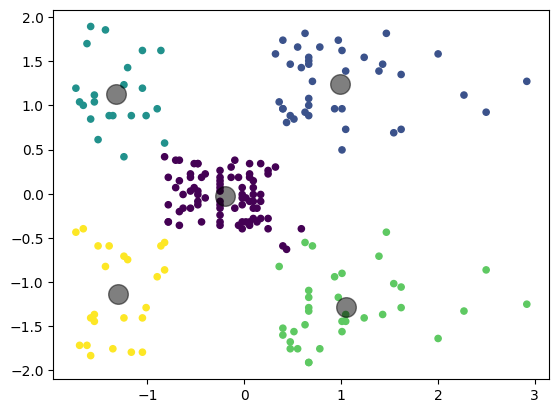

In [67]:
k_means = KMeans(n_clusters=5, random_state=42).fit(X_flat)
y_kmeans = k_means.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_kmeans, s=20, cmap='viridis')
centers = k_means.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.show()

In [68]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X_scaled)

In [69]:
from scipy.cluster.hierarchy import dendrogram
import numpy as np

def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

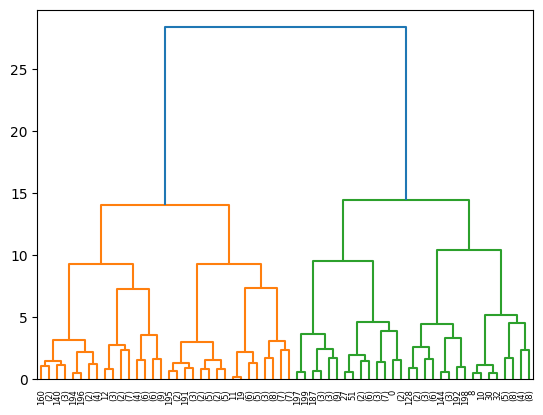

In [70]:
plot_dendrogram(model, truncate_mode="level", p=5)

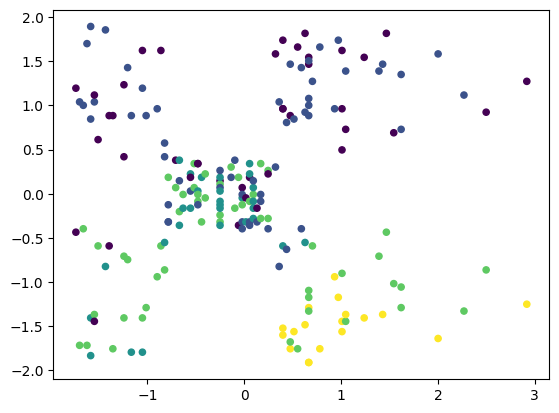

In [71]:
agg_clustering = AgglomerativeClustering(n_clusters=5).fit(X_scaled)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

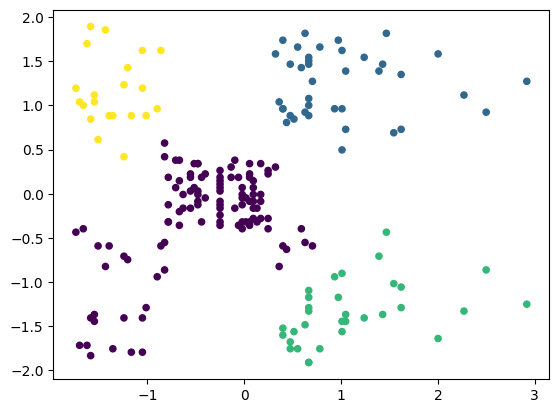

In [72]:
agg_clustering = AgglomerativeClustering(n_clusters=4).fit(X_flat)
y_agg = agg_clustering.labels_

plt.scatter(X_flat.Income, X_flat.Score, c=y_agg, s=20, cmap='viridis')

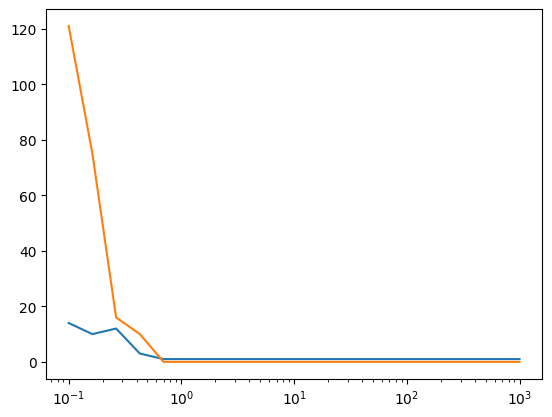

In [73]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

n_clusters_ = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise_ = list(y_db).count(-1)

clusters, noise = [], []
for i in np.logspace(-1, 3, 20):
  db = DBSCAN(eps=i, min_samples=3).fit(X_flat)
  y_db = db.labels_

  clusters.append(len(set(y_db)) - (1 if -1 in y_db else 0))
  noise.append(list(y_db).count(-1))

plt.plot(np.logspace(-1, 3, 20),clusters)
plt.plot(np.logspace(-1, 3, 20),noise)
plt.xscale('log')
_ = plt.show()

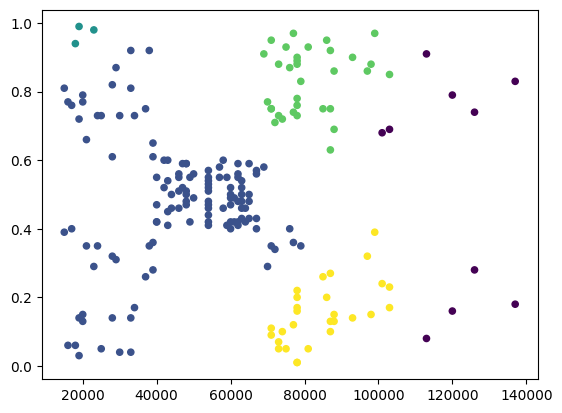

In [74]:
db = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db = db.labels_

plt.scatter(X.Income, X.Score, c=y_db, s=20, cmap='viridis')

## Задания для самостоятельного выполнения

#### 1. Для придания смысла кластерам выведите примеры точек выборки для каждого кластера. Сделайте вывод, чем они отличаются.

In [75]:
from sklearn.cluster import KMeans

kmeans_task1 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
df_task1 = df.copy()
df_task1['cluster'] = kmeans_task1.labels_

print('Размеры кластеров:')
print(df_task1['cluster'].value_counts().sort_index())

print('\nСредние значения признаков по кластерам:')
cluster_stats = df_task1.groupby('cluster')[['Age', 'Income', 'Score']].mean().round(2)
print(cluster_stats)

for c in sorted(df_task1['cluster'].unique()):
    print(f'\nКластер {c}: примеры клиентов')
    print(df_task1[df_task1['cluster'] == c][['CustomerID', 'Genre', 'Age', 'Income', 'Score']].head(5).to_string(index=False))

# Кластеры отличаются в первую очередь доходом (Income) и тратами/активностью (Score)
# Возраст (Age) тоже влияет, но обычно слабее, чем Income и Score на этом датасете

Размеры кластеров:
cluster
0    48
1    56
2    56
3    40
Name: count, dtype: int64

Средние значения признаков по кластерам:
           Age    Income  Score
cluster                        
0        49.44  62416.67   0.29
1        28.39  60428.57   0.68
2        47.80  58071.43   0.35
3        28.25  62000.00   0.72

Кластер 0: примеры клиентов
 CustomerID Genre  Age  Income  Score
          9  Male   64   19000   0.03
         11  Male   67   19000   0.14
         15  Male   37   20000   0.13
         19  Male   52   23000   0.29
         21  Male   35   24000   0.35

Кластер 1: примеры клиентов
 CustomerID  Genre  Age  Income  Score
          4 Female   23   16000   0.77
          6 Female   22   17000   0.76
          8 Female   23   18000   0.94
         10 Female   30   19000   0.72
         12 Female   35   19000   0.99

Кластер 2: примеры клиентов
 CustomerID  Genre  Age  Income  Score
          3 Female   20   16000   0.06
          5 Female   31   17000   0.40
          7 Fem

#### 2. Используйте для визуализации результатов кластеризации другие пары признаков. Сделайте вывод о зависимости кластеризации от признаков.

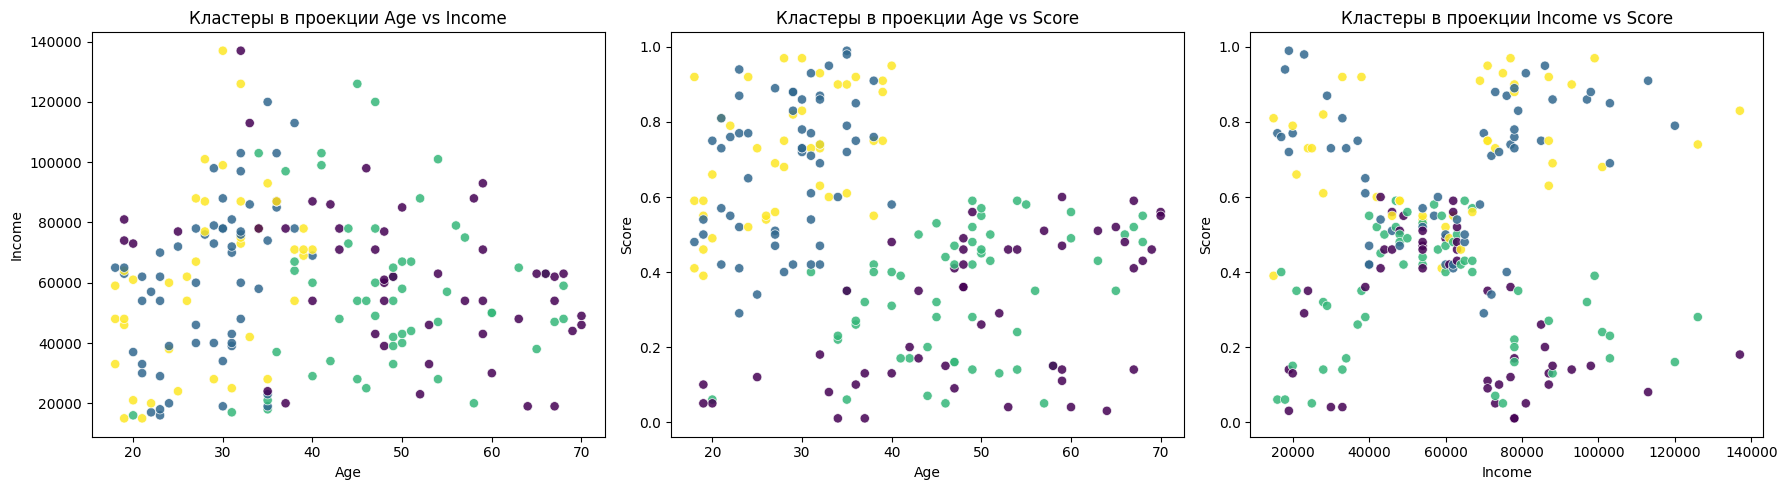

Silhouette-score для KMeans (k=4) на разных парах признаков:
    Age + Income  -> 0.406
    Age + Score   -> 0.438
 Income + Score   -> 0.494


In [76]:
from sklearn.metrics import silhouette_score

pairs = [('Age', 'Income'), ('Age', 'Score'), ('Income', 'Score')]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (f1, f2) in zip(axes, pairs):
    sns.scatterplot(data=df_task1, x=f1, y=f2, hue='cluster', palette='viridis', ax=ax, s=45, alpha=0.85, legend=False)
    ax.set_title(f'Кластеры в проекции {f1} vs {f2}')
plt.tight_layout()
plt.show()

print('Silhouette-score для KMeans (k=4) на разных парах признаков:')
for f1, f2 in pairs:
    X_pair = df[[f1, f2]]
    X_pair_scaled = StandardScaler().fit_transform(X_pair)
    y_pair = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_pair_scaled)
    s = silhouette_score(X_pair_scaled, y_pair)
    print(f'{f1:>7} + {f2:<7} -> {s:.3f}')


# чем информативнее выбранные признаки, тем лучше разделимость (выше silhouette)
# Поэтому итог кластеризации зависит от выбранного поднабора признаков

#### 3. Повторите весь анализ для другого датасета - кластеризации кредитных карт.

Размер датасета: (8950, 18)
Оптимальное k по silhouette: 3


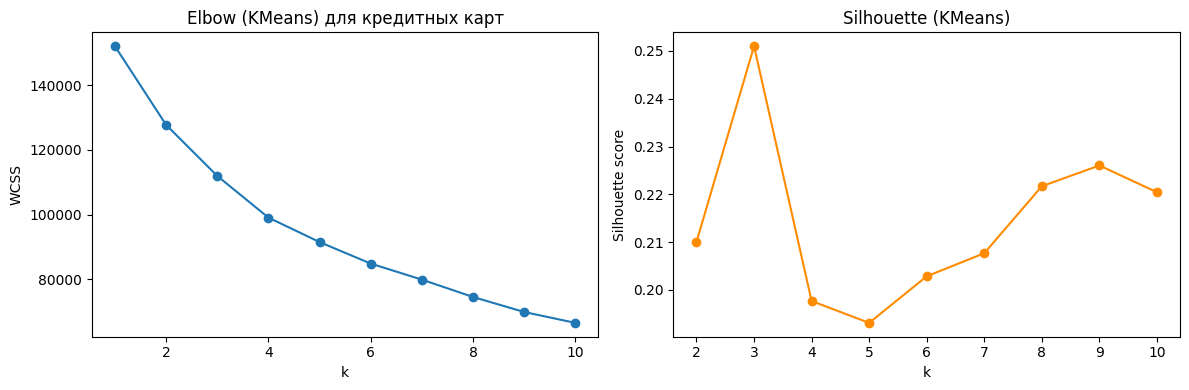

In [77]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

cc = pd.read_csv('data/credit_card_clustering.csv')
print('Размер датасета:', cc.shape)

cc_num = cc.select_dtypes(include='number').copy()
cc_num = cc_num.fillna(cc_num.median(numeric_only=True))

cc_scaled = StandardScaler().fit_transform(cc_num)

wcss_cc = []
sil_cc = []
k_values = range(2, 11)
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(cc_scaled)
    wcss_cc.append(km.inertia_)
    if k >= 2:
        sil_cc.append(silhouette_score(cc_scaled, km.labels_))

k_opt = list(k_values)[int(np.argmax(sil_cc))]
print(f'Оптимальное k по silhouette: {k_opt}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), wcss_cc, marker='o')
plt.title('Elbow (KMeans) для кредитных карт')
plt.xlabel('k')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
plt.plot(list(k_values), sil_cc, marker='o', color='darkorange')
plt.title('Silhouette (KMeans)')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.show()

DBSCAN best: eps=1.70, min_samples=5, silhouette=0.497
DBSCAN: кластеров=2, шумовых точек=961


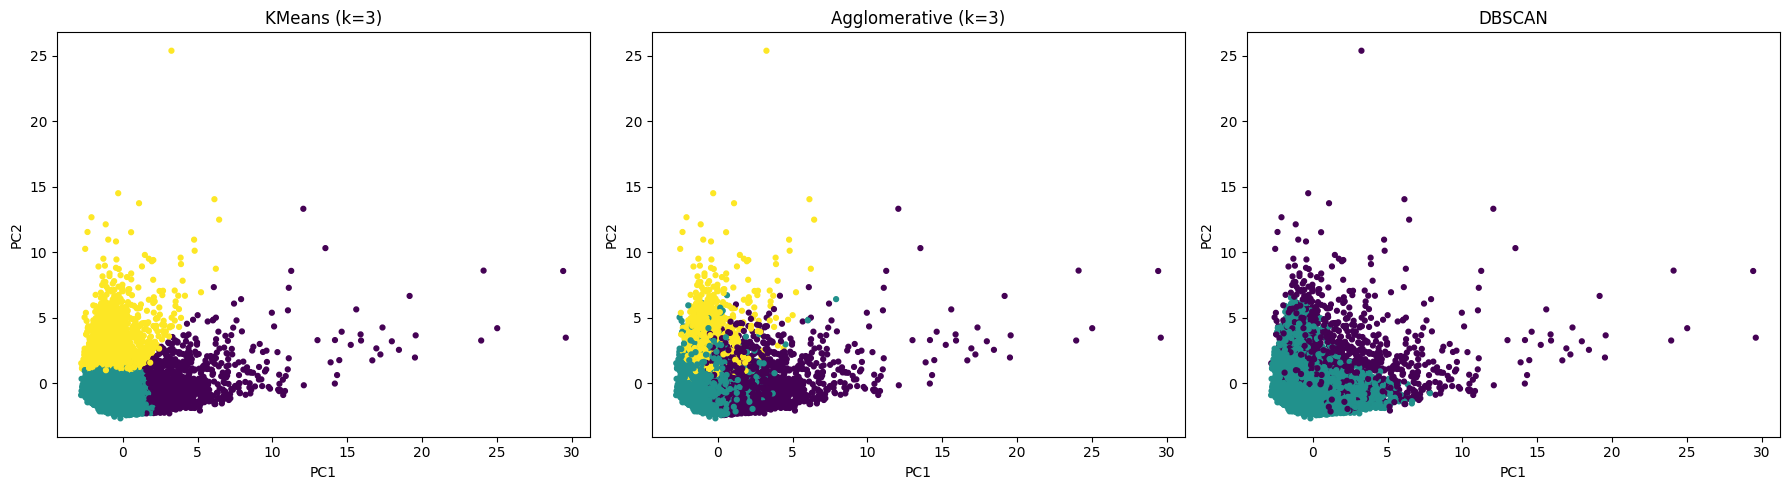

In [78]:
# Обучаем 3 алгоритма
km_cc = KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit(cc_scaled)
y_km_cc = km_cc.labels_

agg_cc = AgglomerativeClustering(n_clusters=k_opt).fit(cc_scaled)
y_agg_cc = agg_cc.labels_

# Простой перебор DBSCAN
best_db = None
best_db_score = -1
best_params = None
for eps in np.linspace(0.5, 2.0, 16):
    for ms in [3, 5, 8, 10]:
        y_tmp = DBSCAN(eps=eps, min_samples=ms).fit_predict(cc_scaled)
        mask = y_tmp != -1
        n_cl = len(set(y_tmp[mask]))
        if n_cl >= 2 and mask.sum() > n_cl:
            score = silhouette_score(cc_scaled[mask], y_tmp[mask])
            if score > best_db_score:
                best_db_score = score
                best_db = y_tmp
                best_params = (eps, ms)

if best_db is None:
    y_db_cc = DBSCAN(eps=1.0, min_samples=5).fit_predict(cc_scaled)
    print('DBSCAN: не найден стабильный вариант по silhouette, взяты параметры eps=1.0, min_samples=5')
else:
    y_db_cc = best_db
    print(f'DBSCAN best: eps={best_params[0]:.2f}, min_samples={best_params[1]}, silhouette={best_db_score:.3f}')

n_db_clusters = len(set(y_db_cc)) - (1 if -1 in y_db_cc else 0)
n_db_noise = int((y_db_cc == -1).sum())
print(f'DBSCAN: кластеров={n_db_clusters}, шумовых точек={n_db_noise}')

# PCA-визуализация для сравнения
pca = PCA(n_components=2, random_state=42)
cc_2d = pca.fit_transform(cc_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(cc_2d[:, 0], cc_2d[:, 1], c=y_km_cc, s=12, cmap='viridis')
axes[0].set_title(f'KMeans (k={k_opt})')

axes[1].scatter(cc_2d[:, 0], cc_2d[:, 1], c=y_agg_cc, s=12, cmap='viridis')
axes[1].set_title(f'Agglomerative (k={k_opt})')

axes[2].scatter(cc_2d[:, 0], cc_2d[:, 1], c=y_db_cc, s=12, cmap='viridis')
axes[2].set_title('DBSCAN')

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

# KMeans и Agglomerative дают близкую сегментацию, DBSCAN сильнее зависит от плотности и параметров

#### 4. В задании на иерархическую кластеризацию используйте разные методы расчета расстояния между кластерами. Сделайте выводы.

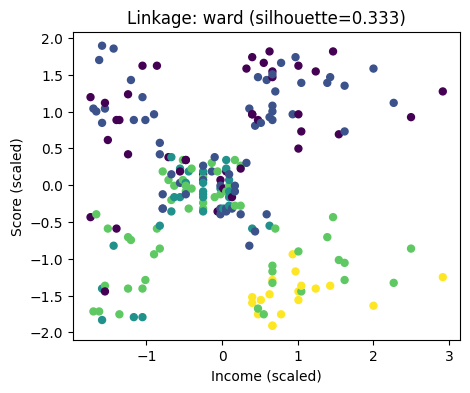

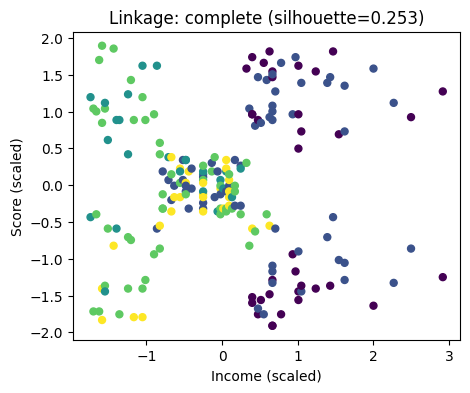

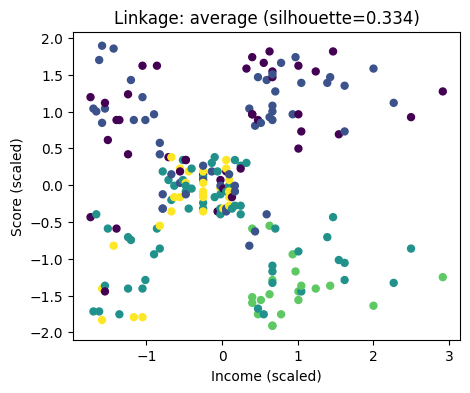

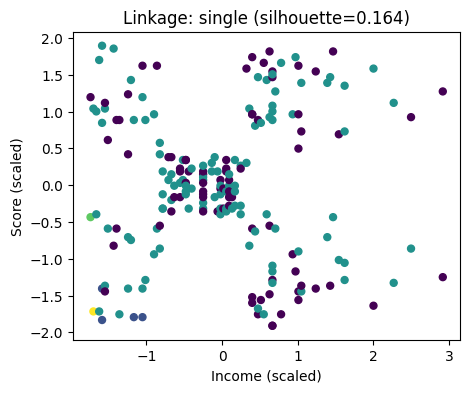

Сравнение linkage-методов по silhouette:
 linkage  silhouette
 average    0.334058
    ward    0.333392
complete    0.252965
  single    0.164491

 для этих данных лучший linkage по silhouette: average.


In [79]:
from sklearn.metrics import silhouette_score

linkages = ['ward', 'complete', 'average', 'single']
results = []

for lk in linkages:
    model_lk = AgglomerativeClustering(n_clusters=5, linkage=lk).fit(X_scaled)
    y_lk = model_lk.labels_
    sil = silhouette_score(X_scaled, y_lk)
    results.append({'linkage': lk, 'silhouette': sil})

    plt.figure(figsize=(5, 4))
    plt.scatter(X_flat['Income'], X_flat['Score'], c=y_lk, s=25, cmap='viridis')
    plt.title(f'Linkage: {lk} (silhouette={sil:.3f})')
    plt.xlabel('Income (scaled)')
    plt.ylabel('Score (scaled)')
    plt.show()

res_df = pd.DataFrame(results).sort_values('silhouette', ascending=False)
print('Сравнение linkage-методов по silhouette:')
print(res_df.to_string(index=False))

best_linkage = res_df.iloc[0]['linkage']
print(f'\n для этих данных лучший linkage по silhouette: {best_linkage}.')

#### 5. В задании на DBSCAN вычислите метрику WCSS и соотнесите результаты кластеризации через DBSCAN и К-средних.

DBSCAN: clusters=4, noise=10, WCSS=128.737, silhouette=0.395
KMeans: clusters=4, noise=0, WCSS=108.921, silhouette=0.494


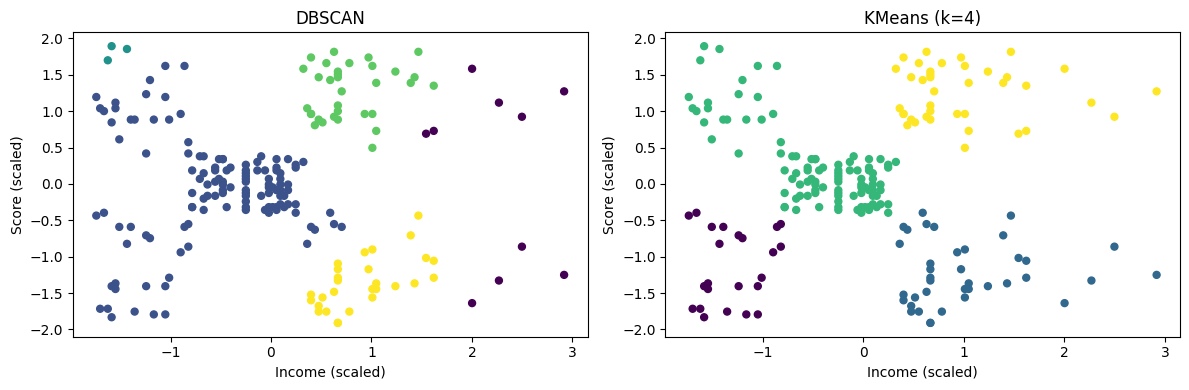

In [80]:
from sklearn.metrics import silhouette_score

def dbscan_wcss(X_array, labels):
    unique_labels = [c for c in np.unique(labels) if c != -1]
    if len(unique_labels) == 0:
        return np.nan

    total = 0.0
    for c in unique_labels:
        points = X_array[labels == c]
        center = points.mean(axis=0)
        total += ((points - center) ** 2).sum()
    return float(total)

db_comp = DBSCAN(eps=0.4, min_samples=3).fit(X_flat)
y_db_comp = db_comp.labels_
db_clusters = len(set(y_db_comp)) - (1 if -1 in y_db_comp else 0)
db_noise = int((y_db_comp == -1).sum())

X_flat_np = X_flat.to_numpy()
wcss_db = dbscan_wcss(X_flat_np, y_db_comp)

k_for_compare = max(db_clusters, 2)
km_comp = KMeans(n_clusters=k_for_compare, random_state=42, n_init=10).fit(X_flat)
y_km_comp = km_comp.labels_
wcss_km = float(km_comp.inertia_)

mask = y_db_comp != -1
if len(set(y_db_comp[mask])) >= 2 and mask.sum() > len(set(y_db_comp[mask])):
    sil_db = silhouette_score(X_flat_np[mask], y_db_comp[mask])
else:
    sil_db = np.nan
sil_km = silhouette_score(X_flat, y_km_comp)

print(f'DBSCAN: clusters={db_clusters}, noise={db_noise}, WCSS={wcss_db:.3f}, silhouette={sil_db:.3f}')
print(f'KMeans: clusters={k_for_compare}, noise=0, WCSS={wcss_km:.3f}, silhouette={sil_km:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_flat['Income'], X_flat['Score'], c=y_db_comp, s=25, cmap='viridis')
axes[0].set_title('DBSCAN')

axes[1].scatter(X_flat['Income'], X_flat['Score'], c=y_km_comp, s=25, cmap='viridis')
axes[1].set_title(f'KMeans (k={k_for_compare})')

for ax in axes:
    ax.set_xlabel('Income (scaled)')
    ax.set_ylabel('Score (scaled)')
plt.tight_layout()
plt.show()

# Вывод: DBSCAN выделяет шум и может давать меньше/больше кластеров, чем KMeans
# WCSS у DBSCAN считаем только по найденным кластерам (без шума), поэтому сравнение интерпретируем аккуратно

#### 6. Постройте кривые WCSS в зависимости от параметров DBSCAN.

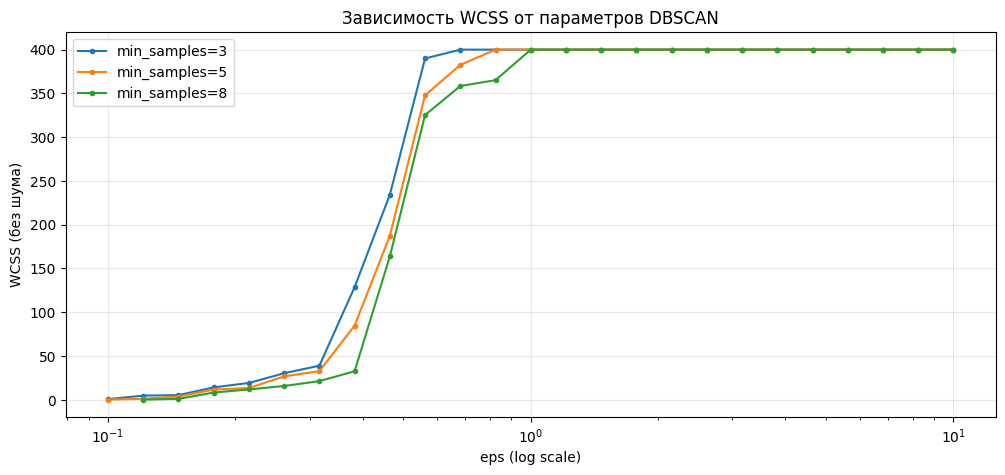

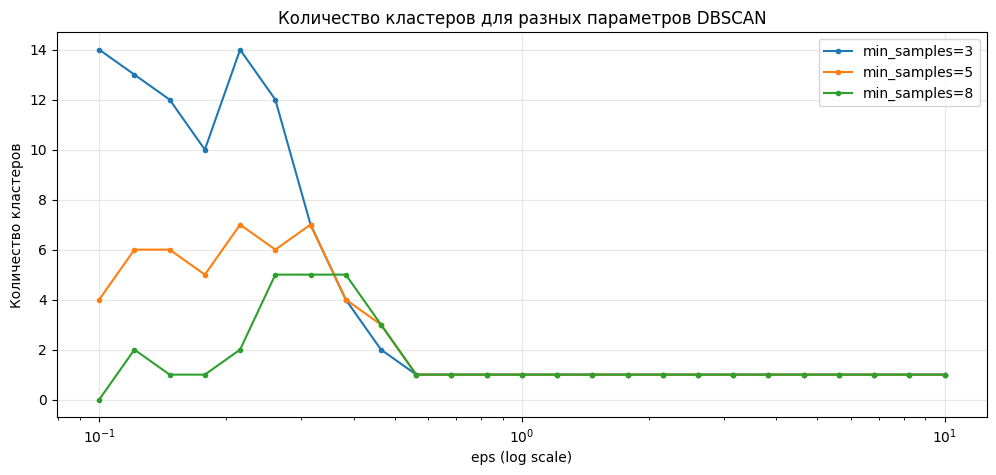

In [81]:
def dbscan_wcss(X_array, labels):
    unique_labels = [c for c in np.unique(labels) if c != -1]
    if len(unique_labels) == 0:
        return np.nan
    total = 0.0
    for c in unique_labels:
        points = X_array[labels == c]
        center = points.mean(axis=0)
        total += ((points - center) ** 2).sum()
    return float(total)

X_flat_np = X_flat.to_numpy()
eps_values = np.logspace(-1, 1, 25)
min_samples_values = [3, 5, 8]

plt.figure(figsize=(12, 5))
for ms in min_samples_values:
    wcss_curve = []
    for eps in eps_values:
        y_tmp = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_flat_np)
        wcss_curve.append(dbscan_wcss(X_flat_np, y_tmp))
    plt.plot(eps_values, wcss_curve, marker='o', markersize=3, label=f'min_samples={ms}')

plt.xscale('log')
plt.xlabel('eps (log scale)')
plt.ylabel('WCSS (без шума)')
plt.title('Зависимость WCSS от параметров DBSCAN')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
for ms in min_samples_values:
    clusters_curve = []
    for eps in eps_values:
        y_tmp = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_flat_np)
        n_cl = len(set(y_tmp)) - (1 if -1 in y_tmp else 0)
        clusters_curve.append(n_cl)
    plt.plot(eps_values, clusters_curve, marker='o', markersize=3, label=f'min_samples={ms}')

plt.xscale('log')
plt.xlabel('eps (log scale)')
plt.ylabel('Количество кластеров')
plt.title('Количество кластеров для разных параметров DBSCAN')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# при росте eps кластеры укрупняются, и WCSS обычно растет после исчезновения шума
# Параметр min_samples делает модель более/менее строгой к плотности